In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix , roc_auc_score , classification_report

In [2]:
path = kagglehub.dataset_download('abhishek14398/sms-spam-collection')
print(path)

100%|██████████| 415k/415k [00:00<00:00, 19.3MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/abhishek14398/sms-spam-collection/versions/2


In [3]:
df =pd.read_csv(f"{path}/SMSSpamCollection.csv")

In [4]:
df.head()

,"ham\tGo until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
0,ham\tOk lar... Joking wif u oni...
1,spam\tFree entry in 2 a wkly comp to win FA Cu...
2,ham\tU dun say so early hor... U c already the...
3,"ham\tNah I don't think he goes to usf, he live..."
4,spam\tFreeMsg Hey there darling it's been 3 we...


In [5]:
df.shape

(5573, 1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 1 columns):
 #   Column                                                                                                               Non-Null Count  Dtype 
---  ------                                                                                                               --------------  ----- 
 0   ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...  5573 non-null   object
dtypes: object(1)
memory usage: 43.7+ KB


In [7]:
df[['label','message']] = df['ham\tGo until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'].str.split('\t', n=1, expand=True)

In [8]:
df.head()

,"ham\tGo until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",label,message
0,ham\tOk lar... Joking wif u oni...,ham,Ok lar... Joking wif u oni...
1,spam\tFree entry in 2 a wkly comp to win FA Cu...,spam,Free entry in 2 a wkly comp to win FA Cup fina...
2,ham\tU dun say so early hor... U c already the...,ham,U dun say so early hor... U c already then say...
3,"ham\tNah I don't think he goes to usf, he live...",ham,"Nah I don't think he goes to usf, he lives aro..."
4,spam\tFreeMsg Hey there darling it's been 3 we...,spam,FreeMsg Hey there darling it's been 3 week's n...


In [9]:
df.isnull().sum()

,0
"ham\tGo until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",0
label,0
message,0


In [10]:
df = df.drop(columns = ['ham\tGo until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'])

In [11]:
df.head()

,label,message
0,ham,Ok lar... Joking wif u oni...
1,spam,Free entry in 2 a wkly comp to win FA Cup fina...
2,ham,U dun say so early hor... U c already then say...
3,ham,"Nah I don't think he goes to usf, he lives aro..."
4,spam,FreeMsg Hey there darling it's been 3 week's n...


In [12]:
df['label'].value_counts()

,count
label,
ham,4826
spam,747


In [13]:
df['spam'] = df['label'].apply(lambda x: 1 if x=='spam' else 0)

In [14]:
df = df.drop(columns = ['label'])

In [15]:
df.head()

,message,spam
0,Ok lar... Joking wif u oni...,0
1,Free entry in 2 a wkly comp to win FA Cup fina...,1
2,U dun say so early hor... U c already then say...,0
3,"Nah I don't think he goes to usf, he lives aro...",0
4,FreeMsg Hey there darling it's been 3 week's n...,1


In [16]:
import re
import string
import pandas as pd
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_message(message):

    message = message.lower()
    message = re.sub(f"[{re.escape(string.punctuation)}]", "", message)
    message = re.sub(r'\d+', '', message)

    tokens = message.split()
    tokens = [word for word in tokens if word not in stop_words]

    cleaned_message = ' '.join(tokens)

    return cleaned_message

df['clean_message'] = df['message'].apply(clean_message)

# comparing original vs cleaned message
print(df[['message', 'clean_message']].head(10))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                             message  \
0                      Ok lar... Joking wif u oni...   
1  Free entry in 2 a wkly comp to win FA Cup fina...   
2  U dun say so early hor... U c already then say...   
3  Nah I don't think he goes to usf, he lives aro...   
4  FreeMsg Hey there darling it's been 3 week's n...   
5  Even my brother is not like to speak with me. ...   
6  As per your request 'Melle Melle (Oru Minnamin...   
7  WINNER!! As a valued network customer you have...   
8  Had your mobile 11 months or more? U R entitle...   
9  I'm gonna be home soon and i don't want to tal...   

                                       clean_message  
0                            ok lar joking wif u oni  
1  free entry wkly comp win fa cup final tkts st ...  
2                u dun say early hor u c already say  
3        nah dont think goes usf lives around though  
4  freemsg hey darling weeks word back id like fu...  
5     even brother like speak treat like aids patent 

In [17]:
X = df['message']
y = df['spam']

In [18]:
X_train,X_test,y_train,y_test = train_test_split(df.clean_message,df.spam,test_size=0.2 , random_state = 2 , stratify = df.spam)

In [19]:
vectorizer ={'CountVectorizer' : CountVectorizer , 'TfidfVectorizer' : TfidfVectorizer}
n_gram = {'unigram' : (1,1) , 'bigram' : (2,2)}
alphas = [0.1,0.5,1,2,5]

results =[]

for vectorizer_name,vectorizeer_class in vectorizer.items():
  for n_gram_name,n_gram_range in n_gram.items():

    vectorizer = vectorizeer_class(ngram_range = n_gram_range)
    X_train_vectorized = vectorizer.fit_transform(X_train)
    X_test_vectorized = vectorizer.transform(X_test)

    for alpha in alphas:
      model = MultinomialNB(alpha = alpha)
      model.fit(X_train_vectorized,y_train)

      y_pred = model.predict(X_test_vectorized)
      y_prob = model.predict_proba(X_test_vectorized)[0:,1]


      results.append({
                'Vectorizer': vectorizer,
                'Alpha': alpha,
                'Accuracy': accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred, zero_division=0),
                'Recall': recall_score(y_test, y_pred, zero_division=0),
                'F1-Score': f1_score(y_test, y_pred, zero_division=0),
                'ROC-AUC': roc_auc_score(y_test, y_prob)})


results_df = pd.DataFrame(results)
results_df.sort_values('F1-Score', ascending=False)

,Vectorizer,Alpha,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,CountVectorizer(),0.1,0.980269,0.926174,0.926174,0.926174,0.973978
10,TfidfVectorizer(),0.1,0.980269,0.963504,0.885906,0.923077,0.986664
1,CountVectorizer(),0.5,0.979372,0.925676,0.919463,0.922559,0.976646
3,CountVectorizer(),2.0,0.978475,0.937063,0.899329,0.917808,0.971873
2,CountVectorizer(),1.0,0.974888,0.911565,0.899329,0.905405,0.975840
6,"CountVectorizer(ngram_range=(2, 2))",0.5,0.975785,0.955224,0.859060,0.904594,0.960562
15,"TfidfVectorizer(ngram_range=(2, 2))",0.1,0.974888,0.923077,0.885906,0.904110,0.963205
4,CountVectorizer(),5.0,0.973991,0.976190,0.825503,0.894545,0.962716
7,"CountVectorizer(ngram_range=(2, 2))",1.0,0.973094,0.954198,0.838926,0.892857,0.960270
5,"CountVectorizer(ngram_range=(2, 2))",0.1,0.970404,0.886667,0.892617,0.889632,0.961177


In [20]:
#for the best pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline


pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB())])


param_grid = {
    'vectorizer': [CountVectorizer(), TfidfVectorizer()],
    'vectorizer__ngram_range': [(1,1), (2,2)],
    'classifier__alpha': [0.1, 0.5, 1, 2, 5]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)
print("Best parameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

Best parameters:  {'classifier__alpha': 2, 'vectorizer': CountVectorizer(), 'vectorizer__ngram_range': (1, 1)}
Best score:  0.9304112041160717


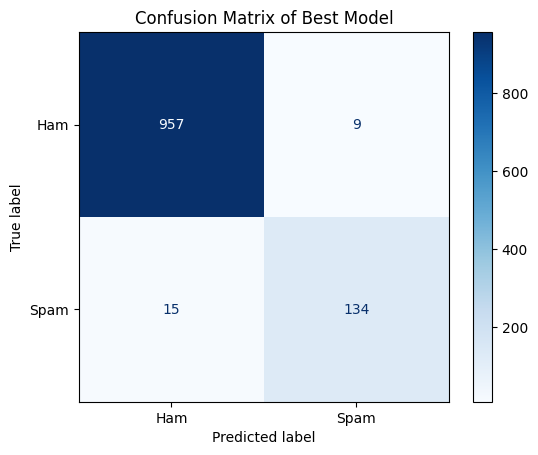

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay , confusion_matrix

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix of Best Model")
plt.show()